<h1 style="text-align:center; margin-bottom: 0.2em;">Soft Optimality of Human Role Coordination</h1>
<p style="text-align:center; font-size:1.1em; color:#555;">Combined Analysis Across Four Pilot Studies</p>
<p style="text-align:center; font-size:0.95em; color:#888;">March 2026</p>

---


## Executive Summary

This report evaluates how well human teams choose role combinations in a cooperative three-player game, using precomputed optimal value functions as a benchmark. We analyze **237 team-stage observations** from **4 pilot studies** (20 games, ~60 players).

**Key results:**

- **Humans play significantly better than random** (p < 0.001). The average team plays the 11th-best combination out of 27 possible (random baseline: 14th). Teams select a top-5 combination 31% of the time (chance: 19%).
- **Strong pilot-level variation**: Two pilots show clear above-chance coordination (p < 0.001), while two others are indistinguishable from random (p > 0.25). This is likely driven by differences in game configuration difficulty across pilots.
- **The inference mechanism works**: Teams improve their role combination quality from stage 1 (blind pick) to stage 3 (after two rounds of observing teammates), with mean rank improving from 11.4 to 9.3.
- **Decision times are consistent** across all pilots: median 15.5 seconds, with stage 2 (first inference opportunity) taking the longest.


## Methodology

### The game

Teams of three players cooperate to defeat a boss enemy. Each player chooses one of three roles (Fighter, Tank, Medic) at the start of each *stage* within a round. After all players choose, the game simulates several turns of combat. If the boss survives, a new stage begins: players see what happened and can switch roles before the next set of turns.

The key coordination challenge is that team performance depends on the *combination* of all three players' roles, not just individual choices. With 3 roles and 3 players, there are 3<sup>3</sup> = **27 possible role combinations**.

### The optimality metric

For each game configuration ("environment"), we precompute an optimal value function V(combo, state) using dynamic programming. This value represents the expected reward from a given game state if the team plays a specific role combination. At each observed team-stage decision, we:

1. Look up the team's current game state (team HP, enemy HP)
2. Compute the expected value of all 27 role combinations at that state
3. **Rank** the team's actual choice from 1 (best) to 27 (worst)

If teams chose randomly, the expected rank would be **(1+27)/2 = 14.0**. Lower ranks indicate better-than-chance coordination.

We also compute **normalized optimality**: (played_value - worst_value) / (best_value - worst_value), which captures how much of the available value gap the team captured. Random play yields ~0.50.

### The Top-K analysis

For a given set of observations, the **Top-K curve** shows: "what fraction of plays fell among the K best combinations?" Under uniform random play, this would be K/27 (a straight diagonal line). If the curve sits *above* the diagonal, teams favor good combinations. If the **Bottom-K curve** sits *below* the diagonal, teams avoid bad combinations.

### Data

We analyze human rounds only (excluding bot rounds), and exclude games with player dropouts ("clean games").


## Data Overview

| Pilot | Date | Games | Clean Team-Stages | Environments | Config Source |
|-------|------|-------|--------------------|--------------|---------------|
| Pilot 1 | Jan 25 | 5 | 70 | FFM, FTM, MFT, TFF | Varied difficulty |
| Pilot 2 | Jan 28 | 5 | 50 | FTM, MFF, MFT, TFM | Harder configs |
| Pilot 3 | Feb 13 | 5 | 48 | FTM, MFF, MFT, TFM | Harder configs |
| Pilot 4 | Mar 06 | 5 | 69 | FFF, FFM, FMM, FTF, FTM, MFF | Curated configs |
| **Total** | | **20** | **237** | **9 unique** | |

Environment labels (e.g., "FTM") indicate the stat-optimal role for each player position. Different pilots used different game configurations (HP levels, boss damage, attack probability), so the same label may correspond to different difficulty levels across pilots. The value lookup always uses the specific configuration for each record.


In [1]:
import numpy as np, pandas as pd, json, os, re, matplotlib.pyplot as plt
from collections import defaultdict
from math import erfc, sqrt
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

BASE = "/Users/jolow/coding/bayesian-role-specialization/analysis"
ENVS_DIR = os.path.join(BASE, "envs")
HUMAN_ENVS_DIR = os.path.join(BASE, "human_envs_value_matrices")
DATA_DIR = os.path.join(BASE, "data")
ROLE_MAP = {"FIGHTER": 0, "TANK": 1, "MEDIC": 2}
ROLE_NAMES = {0: "F", 1: "T", 2: "M"}

PILOTS = {
    "Pilot 1 (Jan 25)": os.path.join(DATA_DIR, "bayesian-role-specialization-2026-01-25-16-53-58"),
    "Pilot 2 (Jan 28)": os.path.join(DATA_DIR, "bayesian-role-specialization-2026-01-28-10-09-10"),
    "Pilot 3 (Feb 13)": os.path.join(DATA_DIR, "bayesian-role-specialization-2026-02-13-10-37-44"),
    "Pilot 4 (Mar 06)": os.path.join(DATA_DIR, "bayesian-role-specialization-2026-03-06-09-54-19"),
}

value_cache = {}
def load_value_matrix(env_id, env_label=None):
    if env_id in value_cache: return value_cache[env_id]
    for base in [ENVS_DIR, HUMAN_ENVS_DIR]:
        for key in [str(env_id), env_label] if env_label else [str(env_id)]:
            if key is None: continue
            p = os.path.join(base, key, "values.npy")
            if os.path.exists(p):
                value_cache[env_id] = np.load(p)
                return value_cache[env_id]
    return None

def extract_from_csv(pilot_name, data_dir):
    games_df = pd.read_csv(os.path.join(data_dir, 'game.csv'))
    players_df = pd.read_csv(os.path.join(data_dir, 'player.csv'))
    records = []
    for _, game_row in games_df.iterrows():
        game_id = game_row['id']
        game_players = players_df[players_df['gameID'] == game_id]
        sro_raw = game_row.get('shuffledRoundOrder')
        if pd.isna(sro_raw): continue
        sro = json.loads(sro_raw) if isinstance(sro_raw, str) else sro_raw
        player_actions = {}
        for _, p_row in game_players.iterrows():
            if pd.isna(p_row.get('gamePlayerId')): continue
            pid = int(p_row['gamePlayerId'])
            ah_raw = p_row.get('actionHistory')
            if pd.notna(ah_raw):
                player_actions[pid] = json.loads(ah_raw) if isinstance(ah_raw, str) else ah_raw
        pids = sorted(player_actions.keys())
        if len(pids) < 3: continue
        pids = pids[:3]
        for rnd_num in range(1, len(sro) + 1):
            if rnd_num - 1 >= len(sro) or sro[rnd_num - 1].get('type') != 'human': continue
            config_col = f'round{rnd_num}Config'
            if config_col not in game_row.index or pd.isna(game_row.get(config_col)): continue
            config = json.loads(game_row[config_col]) if isinstance(game_row[config_col], str) else game_row[config_col]
            env_id = str(config.get('envId', ''))
            optimal_roles = config.get('optimalRoles', [])
            env_label = ''.join(ROLE_NAMES.get(r, '?') for r in optimal_roles)
            thp_max = config.get('maxTeamHealth', 15)
            ehp_max = config.get('maxEnemyHealth', 30)
            eap = config.get('enemyAttackProbability', 0.5)
            all_stages = set()
            for pid in pids:
                for a in player_actions.get(pid, []):
                    if a.get('round') == rnd_num: all_stages.add(a.get('stage', 1))
            if not all_stages: continue
            prev_thp, prev_ehp = thp_max, ehp_max
            for sn in sorted(all_stages):
                roles, st = {}, {}
                for pid in pids:
                    pa = [a for a in player_actions.get(pid, []) if a.get('round') == rnd_num and a.get('stage') == sn]
                    if pa:
                        roles[pid] = ROLE_MAP.get(pa[0].get('role', ''), -1)
                        st[pid] = pa
                if len(roles) != 3 or any(r == -1 for r in roles.values()): continue
                r0, r1, r2 = roles[pids[0]], roles[pids[1]], roles[pids[2]]
                sthp = thp_max if sn == 1 else prev_thp
                sehp = ehp_max if sn == 1 else prev_ehp
                for pid in pids:
                    if pid in st and st[pid]:
                        prev_thp = st[pid][-1].get('teamHealth', prev_thp)
                        prev_ehp = st[pid][-1].get('enemyHealth', prev_ehp)
                        break
                records.append({'pilot': pilot_name, 'game_id': game_id, 'round_num': rnd_num,
                    'env_id': env_id, 'env_label': env_label, 'stage_num': sn,
                    'combo_idx': r0*9+r1*3+r2, 'combo_str': ROLE_NAMES[r0]+ROLE_NAMES[r1]+ROLE_NAMES[r2],
                    'start_team_hp': sthp, 'start_enemy_hp': sehp, 'enemy_attack_prob': eap,
                    'team_max_hp': thp_max, 'enemy_max_hp': ehp_max, 'is_dropout_game': False})
    return records

def extract_from_gamesummary(pilot_name, data_dir):
    players_df = pd.read_csv(os.path.join(data_dir, 'player.csv')).dropna(subset=['gameSummary'])
    has_do = 'isDropout' in players_df.columns
    records = []
    for game_id in players_df['gameID'].unique():
        gp = players_df[players_df['gameID'] == game_id]
        summaries, is_do_game = {}, False
        for _, p_row in gp.iterrows():
            gs = json.loads(p_row['gameSummary']) if isinstance(p_row['gameSummary'], str) else p_row['gameSummary']
            pid = int(gs.get('gamePlayerId', p_row.get('gamePlayerId', -1)))
            summaries[pid] = gs
            if (has_do and p_row.get('isDropout', False)) or gs.get('isDropout', False): is_do_game = True
        pids = sorted(summaries.keys())
        if len(pids) < 3: continue
        pids = pids[:3]
        for rnd in summaries[pids[0]].get('rounds', []):
            if rnd.get('roundType') != 'human': continue
            rn = rnd['roundNumber']
            cfg = rnd.get('config', {})
            env_id = str(cfg.get('envId', ''))
            opt_r = cfg.get('optimalRoles', [])
            env_label = cfg.get('optimalRolesId', ''.join(ROLE_NAMES.get(r, '?') for r in opt_r))
            thp_max = cfg.get('maxTeamHealth', 15)
            ehp_max = cfg.get('maxEnemyHealth', 30)
            eap = cfg.get('enemyAttackProbability', 0.5)
            ps = {}
            for pid in pids:
                pr = next((r for r in summaries[pid].get('rounds', []) if r['roundNumber'] == rn), None)
                if pr: ps[pid] = {s['stage']: s for s in pr.get('stages', [])}
            if len(ps) < 3: continue
            asn = set()
            for pid in pids: asn.update(ps.get(pid, {}).keys())
            prev_thp, prev_ehp = thp_max, ehp_max
            for sn in sorted(asn):
                roles, any_bot = {}, False
                for pid in pids:
                    sd = ps.get(pid, {}).get(sn)
                    if sd:
                        roles[pid] = ROLE_MAP.get(sd.get('role', ''), -1)
                        if sd.get('isBot', False): any_bot = True
                if len(roles) != 3 or any(r == -1 for r in roles.values()): continue
                r0, r1, r2 = roles[pids[0]], roles[pids[1]], roles[pids[2]]
                sthp = thp_max if sn == 1 else prev_thp
                sehp = ehp_max if sn == 1 else prev_ehp
                rs = ps.get(pids[0], {}).get(sn)
                if rs and rs.get('turns'):
                    prev_thp = rs['turns'][-1].get('teamHealth', prev_thp)
                    prev_ehp = rs['turns'][-1].get('enemyHealth', prev_ehp)
                records.append({'pilot': pilot_name, 'game_id': game_id, 'round_num': rn,
                    'env_id': env_id, 'env_label': env_label, 'stage_num': sn,
                    'combo_idx': r0*9+r1*3+r2, 'combo_str': ROLE_NAMES[r0]+ROLE_NAMES[r1]+ROLE_NAMES[r2],
                    'start_team_hp': sthp, 'start_enemy_hp': sehp, 'enemy_attack_prob': eap,
                    'team_max_hp': thp_max, 'enemy_max_hp': ehp_max, 'is_dropout_game': is_do_game or any_bot})
    return records

def get_rank(row):
    v = load_value_matrix(row['env_id'], row.get('env_label'))
    if v is None: return None
    p = row['enemy_attack_prob']
    thp = min(int(row['start_team_hp']), int(row['team_max_hp']))
    ehp = min(int(row['start_enemy_hp']), int(row['enemy_max_hp']))
    if thp < 0 or ehp < 0 or thp >= v.shape[2] or ehp >= v.shape[3]: return None
    vals = (1-p)*v[:,0,thp,ehp] + p*v[:,1,thp,ehp]
    return int(np.where(np.argsort(-vals) == row['combo_idx'])[0][0]) + 1

def get_vinfo(row):
    v = load_value_matrix(row['env_id'], row.get('env_label'))
    if v is None: return (None, None, None)
    p = row['enemy_attack_prob']
    thp = min(int(row['start_team_hp']), int(row['team_max_hp']))
    ehp = min(int(row['start_enemy_hp']), int(row['enemy_max_hp']))
    if thp < 0 or ehp < 0 or thp >= v.shape[2] or ehp >= v.shape[3]: return (None, None, None)
    vals = (1-p)*v[:,0,thp,ehp] + p*v[:,1,thp,ehp]
    return float(vals[row['combo_idx']]), float(vals.max()), float(vals.min())

def compute_topk(ranks, max_k=27):
    n = len(ranks)
    return (np.array([(ranks<=k).sum()/n for k in range(1,max_k+1)]),
            np.array([(ranks>max_k-k).sum()/n for k in range(1,max_k+1)]))

# --- Load all data ---
all_records = []
for name in ["Pilot 1 (Jan 25)", "Pilot 2 (Jan 28)"]:
    all_records.extend(extract_from_csv(name, PILOTS[name]))
for name in ["Pilot 3 (Feb 13)", "Pilot 4 (Mar 06)"]:
    all_records.extend(extract_from_gamesummary(name, PILOTS[name]))

tdf = pd.DataFrame(all_records)
clean = tdf[~tdf['is_dropout_game']].copy()
clean['rank'] = clean.apply(get_rank, axis=1)
vi = clean.apply(get_vinfo, axis=1)
clean['played_val'] = [x[0] for x in vi]
clean['best_val'] = [x[1] for x in vi]
clean['worst_val'] = [x[2] for x in vi]
clean['norm_opt'] = (clean['played_val'] - clean['worst_val']) / (clean['best_val'] - clean['worst_val'])
clean = clean.dropna(subset=['rank'])
clean['rank'] = clean['rank'].astype(int)

ks = np.arange(1, 28)
uniform = ks / 27
pilot_names = sorted(clean['pilot'].unique())
ranks_all = clean['rank']
top_k_all, bottom_k_all = compute_topk(ranks_all)

print(f"Data loaded: {len(clean)} clean team-stage records across {len(pilot_names)} pilots, {len(value_cache)} environments.")


Data loaded: 237 clean team-stage records across 4 pilots, 16 environments.


## Result 1: Overall Soft Optimality

The figure below shows the Top-K and Bottom-K curves aggregated across all pilots. Each point on the **blue Top-K curve** shows the fraction of team-stage observations where the team's chosen role combination was among the K best (out of 27). The **red Bottom-K curve** shows the fraction among the K worst. The dashed diagonal is the baseline for uniform random play.

**How to read the plot**: If the blue curve is above the diagonal, humans are biased toward better combinations. If the red curve is below the diagonal, humans avoid bad combinations.


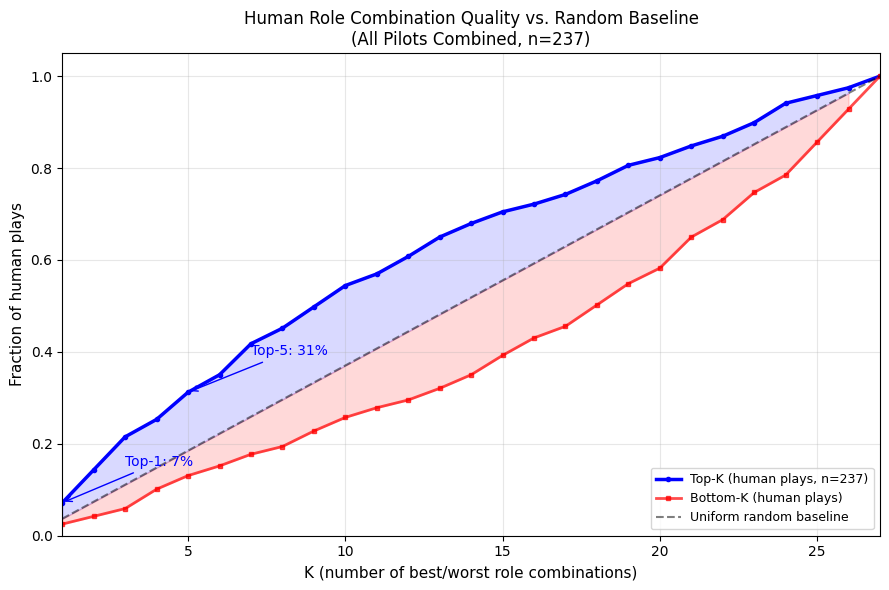

In [2]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.fill_between(ks, top_k_all, uniform, where=(top_k_all > uniform), alpha=0.15, color='blue')
ax.fill_between(ks, bottom_k_all, uniform, where=(bottom_k_all < uniform), alpha=0.15, color='red')
ax.plot(ks, top_k_all, 'b-o', markersize=3, linewidth=2.5, label=f'Top-K (human plays, n={len(ranks_all)})')
ax.plot(ks, bottom_k_all, 'r-s', markersize=3, linewidth=2, alpha=0.7, label='Bottom-K (human plays)')
ax.plot(ks, uniform, 'k--', alpha=0.5, linewidth=1.5, label='Uniform random baseline')
ax.set_xlabel('K (number of best/worst role combinations)', fontsize=11)
ax.set_ylabel('Fraction of human plays', fontsize=11)
ax.set_title('Human Role Combination Quality vs. Random Baseline\n(All Pilots Combined, n=237)', fontsize=12)
ax.annotate(f'Top-1: {top_k_all[0]:.0%}', xy=(1, top_k_all[0]), xytext=(3, top_k_all[0]+0.08),
            arrowprops=dict(arrowstyle='->', color='blue'), fontsize=10, color='blue')
ax.annotate(f'Top-5: {top_k_all[4]:.0%}', xy=(5, top_k_all[4]), xytext=(7, top_k_all[4]+0.08),
            arrowprops=dict(arrowstyle='->', color='blue'), fontsize=10, color='blue')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(1, 27); ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


**Interpretation**: The Top-K curve (blue) sits consistently above the random baseline, and the Bottom-K curve (red) sits below it. This means human teams are both drawn toward good combinations and repelled from bad ones. Specifically:

- **31% of plays are in the top 5** (random expectation: 19%)
- **Only 13% of plays are in the bottom 5** (random expectation: 19%)
- **Mean rank: 11.2** vs. 14.0 expected under random play (p < 0.001, one-sided z-test)

The effect is statistically significant but modest in magnitude. Teams do better than chance, but they are far from optimal.


## Result 2: Pilot-Level Comparison

Not all pilots show the same pattern. The figure below shows the Top-K / Bottom-K curves separately for each pilot, allowing direct comparison of play quality across the four data collection sessions.


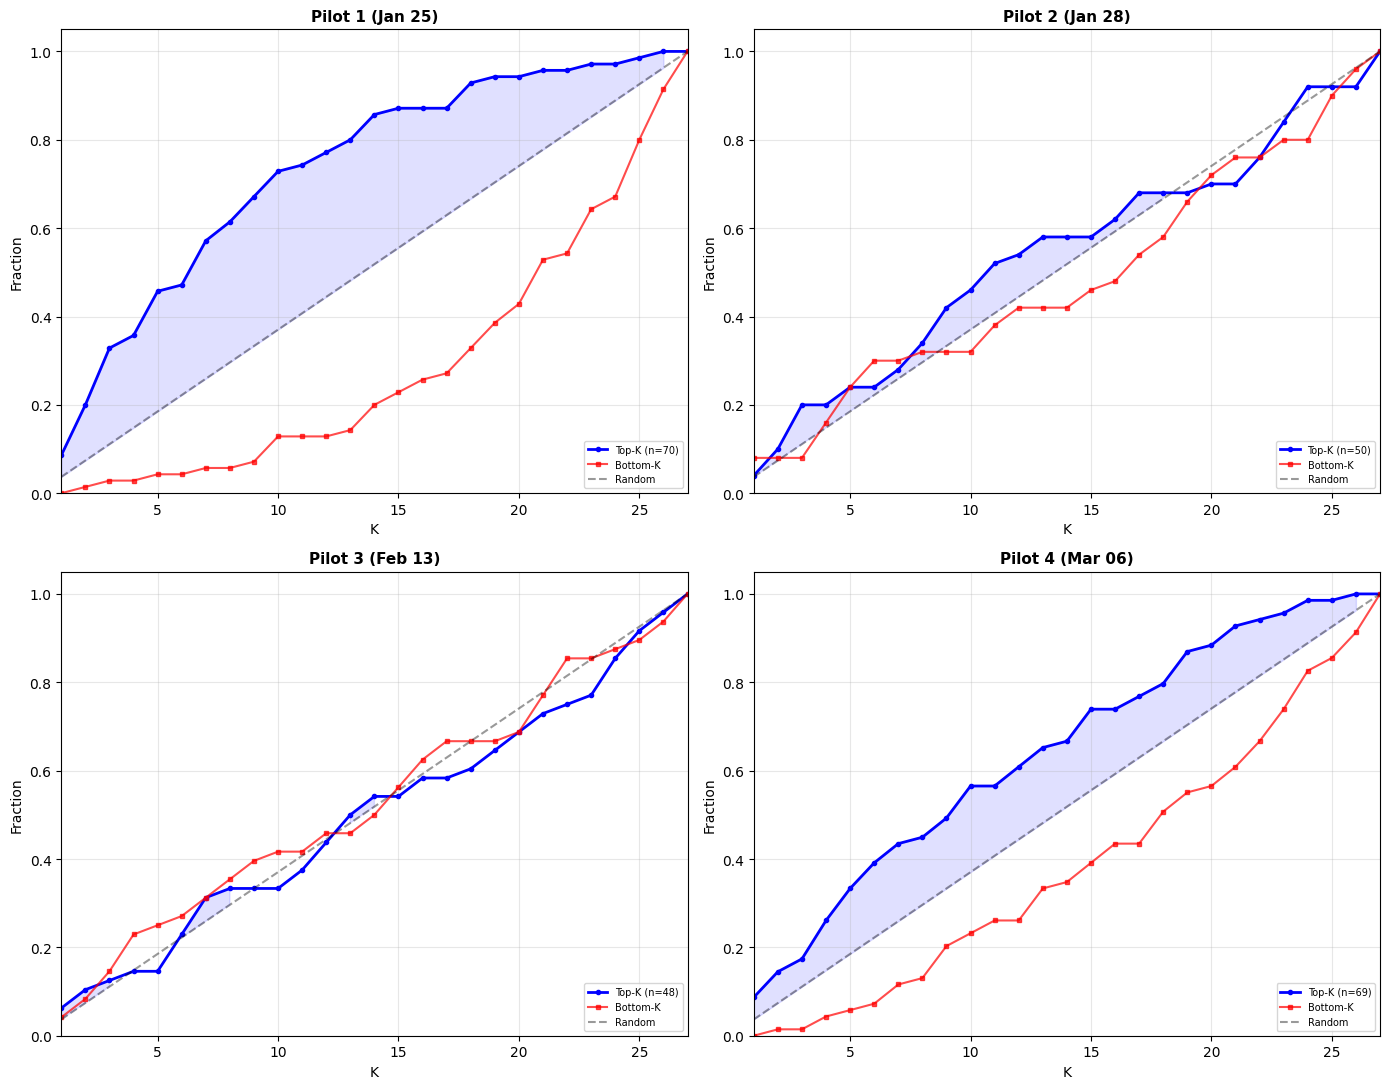

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for idx, pilot in enumerate(pilot_names):
    ax = axes[idx // 2, idx % 2]
    r = clean[clean['pilot'] == pilot]['rank']
    tk, bk = compute_topk(r)
    ax.fill_between(ks, tk, uniform, where=(tk > uniform), alpha=0.12, color='blue')
    ax.plot(ks, tk, 'b-o', ms=3, lw=2, label=f'Top-K (n={len(r)})')
    ax.plot(ks, bk, 'r-s', ms=3, lw=1.5, alpha=0.7, label='Bottom-K')
    ax.plot(ks, uniform, 'k--', alpha=0.4, label='Random')
    ax.set_title(f'{pilot}', fontsize=11, fontweight='bold')
    ax.set_xlabel('K'); ax.set_ylabel('Fraction')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlim(1, 27); ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


In [4]:
# Summary table by pilot
print(f"{'Pilot':<20} {'N':>4} {'Mean':>6} {'Med':>5} {'Top-5':>7} {'Bot-5':>7} {'NormOpt':>8} {'p-value':>9}")
print(f"{'':.<20} {'':.<4} {'Rank':.<6} {'Rank':.<5} {'(%)':.<7} {'(%)':.<7} {'':.<8} {'':.<9}")
print('-' * 75)
for pilot in pilot_names + ['ALL PILOTS']:
    r = clean['rank'] if pilot == 'ALL PILOTS' else clean[clean['pilot']==pilot]['rank']
    no = clean['norm_opt'].dropna() if pilot == 'ALL PILOTS' else clean[clean['pilot']==pilot]['norm_opt'].dropna()
    n = len(r)
    se = sqrt((27**2-1)/12/n)
    z = (r.mean()-14)/se
    p = 0.5*erfc(-z/sqrt(2))
    pstr = f'{p:.4f}' if p >= 0.001 else '<0.001'
    lbl = f'  {pilot}' if pilot != 'ALL PILOTS' else f'**{pilot}**'
    print(f"{pilot:<20} {n:>4} {r.mean():>6.1f} {r.median():>5.0f} {100*(r<=5).mean():>6.0f}% {100*(r>22).mean():>6.0f}% {no.mean():>8.2f} {pstr:>9}")
print('-' * 75)
print(f"{'Random baseline':<20} {'':>4} {'14.0':>6} {'14':>5} {'19%':>7} {'19%':>7} {'0.50':>8}")


Pilot                   N   Mean   Med   Top-5   Bot-5  NormOpt   p-value
.................... .... Rank.. Rank. (%).... (%).... ........ .........
---------------------------------------------------------------------------
Pilot 1 (Jan 25)       70    8.1     7     46%      4%     0.64    <0.001
Pilot 2 (Jan 28)       50   13.3    11     24%     24%     0.34    0.2509
Pilot 3 (Feb 13)       48   14.4    14     15%     25%     0.28    0.6376
Pilot 4 (Mar 06)       69   10.6    10     33%      6%     0.57    <0.001
ALL PILOTS            237   11.2    10     31%     13%     0.48    <0.001
---------------------------------------------------------------------------
Random baseline             14.0    14     19%     19%     0.50


**Interpretation**: There is a clear split between pilots:

- **Pilot 1** (Jan 25) and **Pilot 4** (Mar 06) show strong above-chance play (p < 0.001). Pilot 1 is the strongest: mean rank 8.1, with 46% of plays in the top 5.
- **Pilot 2** (Jan 28) and **Pilot 3** (Feb 13) are not statistically distinguishable from random play (p = 0.25 and 0.64). Notably, these pilots also have high bottom-5 rates (24-25%), meaning players sometimes select near-worst combinations.

**Why the difference?** Pilots 2 and 3 used the same set of harder game configurations (FTM, MFF, MFT, TFM), while Pilot 1 used configurations where the optimal role assignment was more obvious from players' stat profiles, and Pilot 4 used a curated set designed for balanced difficulty. This suggests that **configuration difficulty is the primary driver of observed play quality**, rather than differences in player skill across sessions.


The overlay below places all four pilots on one chart for direct visual comparison, with the aggregated curve in black.


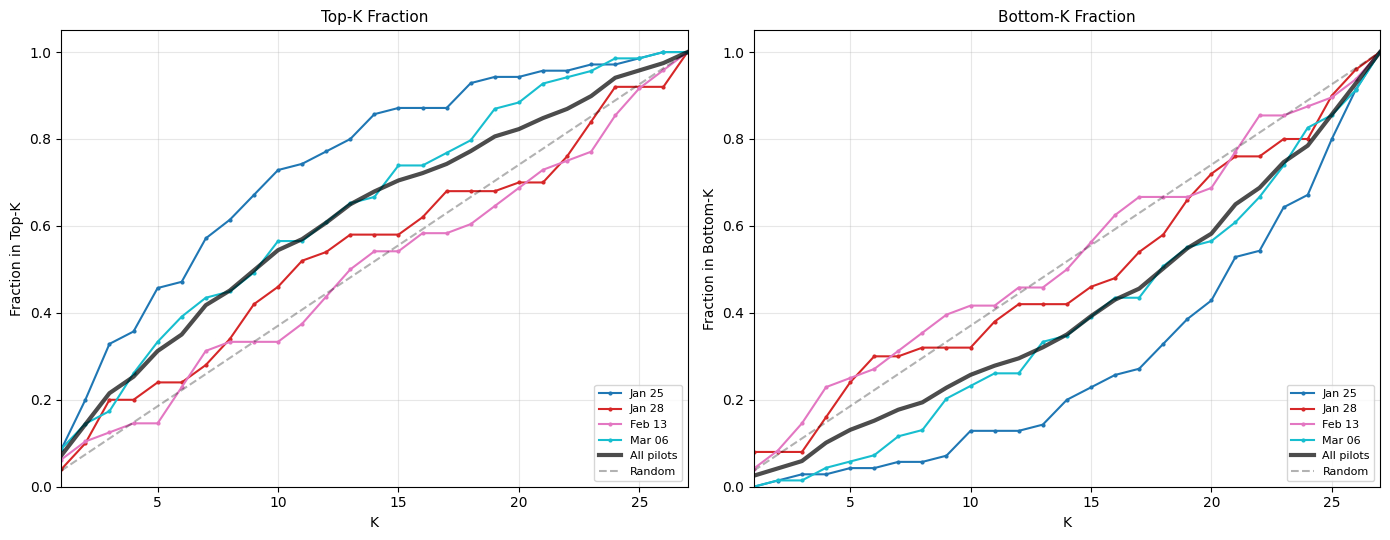

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
colors = plt.cm.tab10(np.linspace(0, 1, len(pilot_names)))
for ax, metric, title in zip(axes, ['top','bottom'], ['Top-K','Bottom-K']):
    for idx, pilot in enumerate(pilot_names):
        r = clean[clean['pilot']==pilot]['rank']
        tk, bk = compute_topk(r)
        ax.plot(ks, tk if metric=='top' else bk, '-o', ms=2, color=colors[idx], lw=1.5,
                label=pilot.split('(')[1].rstrip(')'))
    tk_a, bk_a = compute_topk(ranks_all)
    ax.plot(ks, tk_a if metric=='top' else bk_a, 'k-', lw=3, alpha=0.7, label='All pilots')
    ax.plot(ks, uniform, 'k--', alpha=0.3, label='Random')
    ax.set_title(f'{title} Fraction', fontsize=11)
    ax.set_xlabel('K'); ax.set_ylabel(f'Fraction in {title}')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim(1, 27); ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Result 3: Environment-Level Comparison

Each environment (identified by its stat-optimal role profile, e.g., "FTM" means the stat-optimal roles are Fighter, Tank, Medic for players 1-3) may present different coordination challenges. The table below summarizes play quality by environment, pooled across pilots.


In [6]:
env_labels = sorted(clean['env_label'].unique())
print(f"{'Environment':<12} {'N':>4} {'Pilots':>6} {'Mean':>6} {'Med':>5} {'Top-5':>7} {'Bot-5':>7} {'NormOpt':>8} {'p-value':>9}")
print(f"{'':.<12} {'':.<4} {'':.<6} {'Rank':.<6} {'Rank':.<5} {'(%)':.<7} {'(%)':.<7} {'':.<8} {'':.<9}")
print('-' * 75)
for el in env_labels + ['ALL']:
    r = clean['rank'] if el=='ALL' else clean[clean['env_label']==el]['rank']
    no = clean['norm_opt'].dropna() if el=='ALL' else clean[clean['env_label']==el]['norm_opt'].dropna()
    np_ = clean['pilot'].nunique() if el=='ALL' else clean[clean['env_label']==el]['pilot'].nunique()
    n = len(r)
    se = sqrt((27**2-1)/12/n)
    z = (r.mean()-14)/se
    p = 0.5*erfc(-z/sqrt(2))
    pstr = f'{p:.4f}' if p >= 0.001 else '<0.001'
    print(f"{el:<12} {n:>4} {np_:>6} {r.mean():>6.1f} {r.median():>5.0f} {100*(r<=5).mean():>6.0f}% {100*(r>22).mean():>6.0f}% {no.mean():>8.2f} {pstr:>9}")
print('-' * 75)
print(f"{'Random':<12} {'':>4} {'':>6} {'14.0':>6} {'14':>5} {'19%':>7} {'19%':>7} {'0.50':>8}")


Environment     N Pilots   Mean   Med   Top-5   Bot-5  NormOpt   p-value
............ .... ...... Rank.. Rank. (%).... (%).... ........ .........
---------------------------------------------------------------------------
FFF             9      1    9.8    10     33%      0%     0.72    0.0519
FFM            34      2    8.4     7     38%      3%     0.80    <0.001
FMM            10      1   13.5    16     30%     20%     0.59    0.4196
FTF            12      1    9.8     8     42%      0%     0.62    0.0319
FTM            62      4   12.3    12     26%     16%     0.34    0.0405
MFF            47      3   12.5    11     28%     23%     0.37    0.0888
MFT            17      3   10.5     8     35%      6%     0.41    0.0309
TFF            30      1    8.8     8     43%      7%     0.51    <0.001
TFM            16      2   14.4    14     12%     25%     0.41    0.5889
ALL           237      4   11.2    10     31%     13%     0.48    <0.001
------------------------------------------------

**Interpretation**: Environments where each player has a clearly differentiated stat profile (e.g., TFF, FFM, FTF) tend to produce better coordination. In these cases, players can more easily infer the "right" role from their own stats and those suggested by teammates' behavior. Environments with ambiguous or overlapping stat profiles (e.g., TFM, MFF) produce near-random play, likely because the optimal combination is harder to discover through observation alone.


## Result 4: Within-Round Learning (Stage Progression)

Within each round, players make role choices at multiple *stages*. At stage 1, they pick blindly. At each subsequent stage, they can observe what happened in the previous turns and revise their role. If the inference mechanism is working, we should see play quality improve over stages.

The left panel shows **mean rank** by stage (lower is better); the right panel shows **normalized optimality** (higher is better). Error bars are 95% confidence intervals.


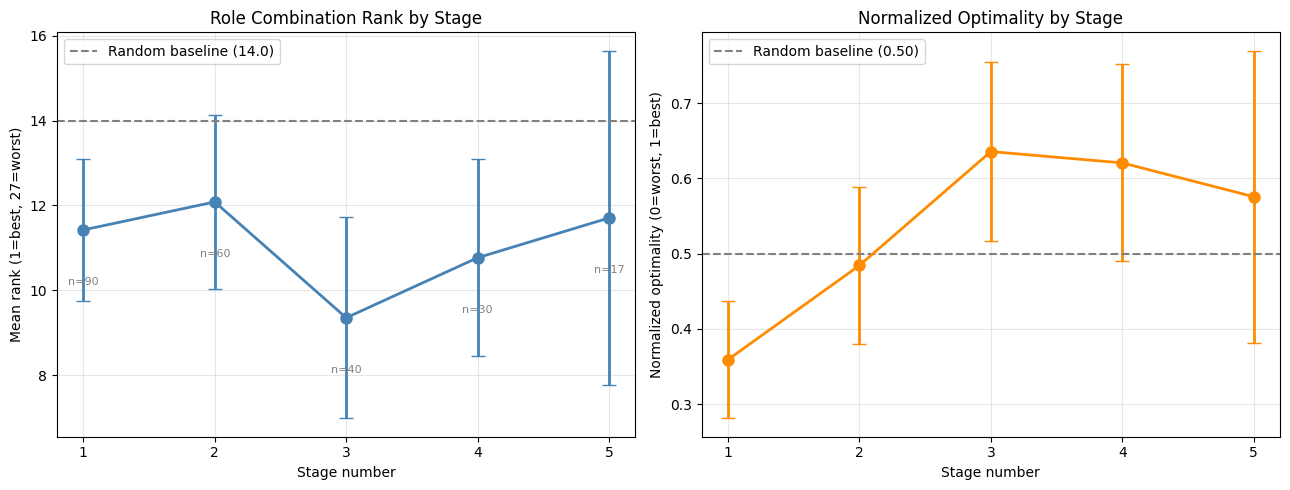

Stage-level summary:
  Stage 1: n= 90,  mean rank=11.4,  norm_opt=0.36,  top-5=32%
  Stage 2: n= 60,  mean rank=12.1,  norm_opt=0.48,  top-5=30%
  Stage 3: n= 40,  mean rank=9.3,  norm_opt=0.64,  top-5=40%
  Stage 4: n= 30,  mean rank=10.8,  norm_opt=0.62,  top-5=23%
  Stage 5: n= 17,  mean rank=11.7,  norm_opt=0.58,  top-5=24%


In [7]:
stage_nums = sorted(clean['stage_num'].unique())
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

means = [clean[clean['stage_num']==s]['rank'].mean() for s in stage_nums]
sems = [clean[clean['stage_num']==s]['rank'].sem() for s in stage_nums]
ns = [len(clean[clean['stage_num']==s]) for s in stage_nums]
ax = axes[0]
ax.errorbar(stage_nums, means, yerr=[1.96*s for s in sems], fmt='o-', color='steelblue', capsize=5, lw=2, ms=8)
ax.axhline(y=14, color='gray', ls='--', lw=1.5, label='Random baseline (14.0)')
for s, m, n in zip(stage_nums, means, ns): ax.text(s, m-1.3, f'n={n}', ha='center', fontsize=8, color='gray')
ax.set_xlabel('Stage number'); ax.set_ylabel('Mean rank (1=best, 27=worst)')
ax.set_title('Role Combination Rank by Stage'); ax.set_xticks(stage_nums); ax.legend(); ax.grid(True, alpha=0.3)

mno = [clean[clean['stage_num']==s]['norm_opt'].mean() for s in stage_nums]
sno = [clean[clean['stage_num']==s]['norm_opt'].sem() for s in stage_nums]
ax = axes[1]
ax.errorbar(stage_nums, mno, yerr=[1.96*s for s in sno], fmt='o-', color='darkorange', capsize=5, lw=2, ms=8)
ax.axhline(y=0.5, color='gray', ls='--', lw=1.5, label='Random baseline (0.50)')
ax.set_xlabel('Stage number'); ax.set_ylabel('Normalized optimality (0=worst, 1=best)')
ax.set_title('Normalized Optimality by Stage'); ax.set_xticks(stage_nums); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("Stage-level summary:")
for s in stage_nums:
    d = clean[clean['stage_num']==s]
    print(f"  Stage {s}: n={len(d):>3},  mean rank={d['rank'].mean():.1f},  norm_opt={d['norm_opt'].mean():.2f},  top-5={100*(d['rank']<=5).mean():.0f}%")


**Interpretation**: Both metrics show improvement from the initial blind pick (stage 1) to stage 3:

- **Mean rank improves** from 11.4 (stage 1) to 9.3 (stage 3) — a shift of about 2 positions toward the optimum
- **Normalized optimality improves** from 0.36 to 0.64, crossing above the random baseline (0.50)

This is direct evidence that the inference mechanism is working: after observing teammates' behavior for two stage boundaries, teams converge toward better role assignments. The improvement plateaus at stages 4-5, though sample sizes shrink in later stages (only rounds that haven't ended yet contribute), introducing a survivorship bias — later-stage observations come disproportionately from winning rounds.


## Result 5: Decision Timing

Beyond *what* players choose, we can examine *how long* they take. Decision time is measured as the interval between a stage starting and the player submitting their role choice. This provides a behavioral indicator of cognitive effort and deliberation.


In [8]:
def load_timing(pilot_name, data_dir):
    stages_df = pd.read_csv(os.path.join(data_dir, 'stage.csv'))
    ps_df = pd.read_csv(os.path.join(data_dir, 'playerStage.csv'))
    rounds_df = pd.read_csv(os.path.join(data_dir, 'round.csv'))
    players_df = pd.read_csv(os.path.join(data_dir, 'player.csv'))
    rtm = {}
    if 'gameSummary' in players_df.columns:
        for _, row in players_df.dropna(subset=['gameSummary']).iterrows():
            gs = json.loads(row['gameSummary']) if isinstance(row['gameSummary'], str) else row['gameSummary']
            for rnd in gs.get('rounds', gs.get('roundResults', [])):
                rtm[(row['gameID'], rnd.get('roundNumber'))] = rnd.get('roundType', 'unknown')
    if not rtm:
        games_df = pd.read_csv(os.path.join(data_dir, 'game.csv'))
        for _, gr in games_df.iterrows():
            sr = gr.get('shuffledRoundOrder')
            if pd.isna(sr): continue
            sr = json.loads(sr) if isinstance(sr, str) else sr
            for i, e in enumerate(sr): rtm[(gr['id'], i+1)] = e.get('type', 'unknown')
    ri = rounds_df[['id','gameID','roundNumber']].copy()
    ri['roundType'] = ri.apply(lambda r: rtm.get((r['gameID'], r['roundNumber']), 'unknown'), axis=1)
    sc = [c for c in ['id','gameID','stageNumber','stageStartedAt','stageEndedAt','stageType','roundID'] if c in stages_df.columns]
    ps = ps_df.merge(stages_df[sc], left_on='stageID', right_on='id', suffixes=('','_s'))
    ps = ps.merge(ri[['id','roundNumber','roundType']].rename(columns={'id':'rid'}), left_on='roundID', right_on='rid', how='left')
    ps['dt_s'] = (ps['roleSubmittedAt'] - ps['stageStartedAt']) / 1000
    ps['is_auto'] = ps['autoSubmitted']==True if 'autoSubmitted' in ps.columns else False
    ps['stageNumber'] = pd.to_numeric(ps['stageNumber'], errors='coerce')
    mask = (ps['roundType']=='human') & (~ps['is_auto']) & (ps['dt_s']>0) & (ps['dt_s']<300) & ps['stageNumber'].notna()
    if 'stageType' in ps.columns: mask = mask & ps['stageType'].isna()
    r = ps[mask].copy(); r['pilot'] = pilot_name
    return r

timing_df = pd.concat([load_timing(n, d) for n, d in PILOTS.items()], ignore_index=True)
timing_df['stageNumber'] = timing_df['stageNumber'].astype(int)
print(f"Decision time records: {len(timing_df)} across {timing_df['pilot'].nunique()} pilots")


Decision time records: 756 across 4 pilots


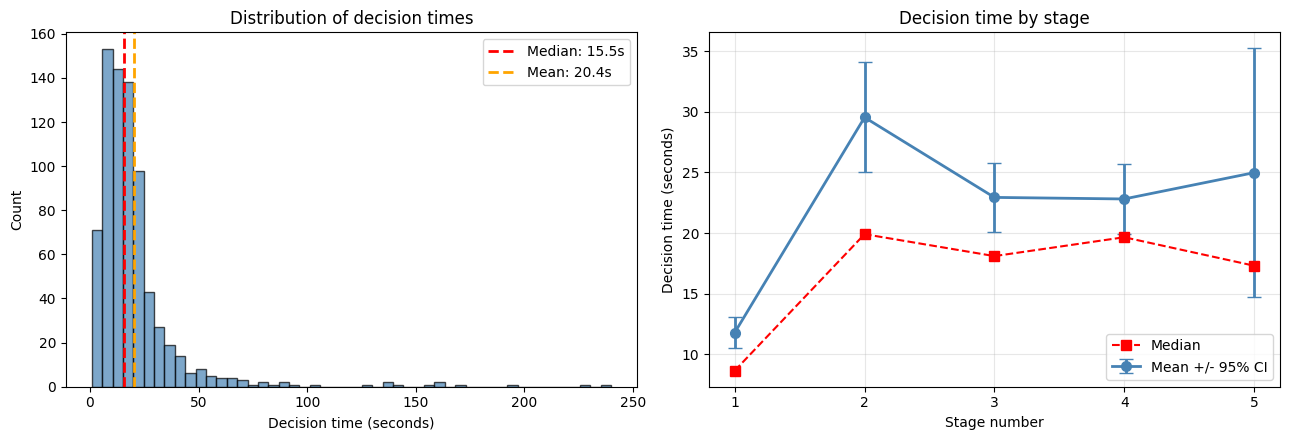

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histogram
ax = axes[0]
ax.hist(timing_df['dt_s'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(timing_df['dt_s'].median(), color='red', ls='--', lw=2, label=f'Median: {timing_df["dt_s"].median():.1f}s')
ax.axvline(timing_df['dt_s'].mean(), color='orange', ls='--', lw=2, label=f'Mean: {timing_df["dt_s"].mean():.1f}s')
ax.set_xlabel('Decision time (seconds)'); ax.set_ylabel('Count')
ax.set_title('Distribution of decision times'); ax.legend()

# Right: by stage
ax = axes[1]
sns_t = sorted(timing_df['stageNumber'].unique())
means_t = [timing_df[timing_df['stageNumber']==s]['dt_s'].mean() for s in sns_t]
meds_t = [timing_df[timing_df['stageNumber']==s]['dt_s'].median() for s in sns_t]
sems_t = [timing_df[timing_df['stageNumber']==s]['dt_s'].sem() for s in sns_t]
ax.errorbar(sns_t, means_t, yerr=[1.96*s for s in sems_t], fmt='o-', color='steelblue', capsize=5, lw=2, ms=7, label='Mean +/- 95% CI')
ax.plot(sns_t, meds_t, 's--', color='red', ms=7, lw=1.5, label='Median')
ax.set_xlabel('Stage number'); ax.set_ylabel('Decision time (seconds)')
ax.set_title('Decision time by stage'); ax.set_xticks(sns_t); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


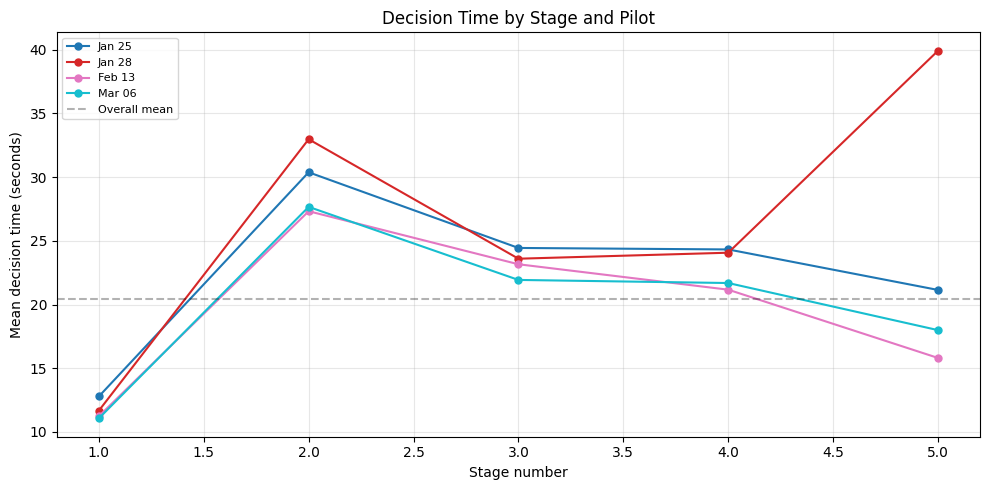

Per-pilot summary:
  Pilot 1 (Jan 25): n=212, mean=20.9s, median=17.1s
  Pilot 2 (Jan 28): n=172, mean=22.5s, median=16.4s
  Pilot 3 (Feb 13): n=152, mean=17.7s, median=11.2s
  Pilot 4 (Mar 06): n=220, mean=20.3s, median=15.9s

Per-stage summary:
  Stage 1: n=293, mean=11.8s, median=8.6s
  Stage 2: n=194, mean=29.5s, median=19.9s
  Stage 3: n=127, mean=22.9s, median=18.1s
  Stage 4: n= 91, mean=22.8s, median=19.7s
  Stage 5: n= 51, mean=25.0s, median=17.3s


In [10]:
# Per-pilot timing
fig, ax = plt.subplots(figsize=(10, 5))
pnames = sorted(timing_df['pilot'].unique())
colors_l = plt.cm.tab10(np.linspace(0, 1, len(pnames)))
for idx, pilot in enumerate(pnames):
    pdf = timing_df[timing_df['pilot']==pilot]
    stages = sorted(pdf['stageNumber'].unique())
    means_p = [pdf[pdf['stageNumber']==s]['dt_s'].mean() for s in stages]
    ax.plot(stages, means_p, '-o', color=colors_l[idx], lw=1.5, ms=5, label=pilot.split('(')[1].rstrip(')'))
ax.axhline(y=timing_df['dt_s'].mean(), color='black', ls='--', alpha=0.3, label='Overall mean')
ax.set_xlabel('Stage number'); ax.set_ylabel('Mean decision time (seconds)')
ax.set_title('Decision Time by Stage and Pilot'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("Per-pilot summary:")
for pilot in pnames:
    d = timing_df[timing_df['pilot']==pilot]['dt_s']
    print(f"  {pilot}: n={len(d):>3}, mean={d.mean():.1f}s, median={d.median():.1f}s")
print(f"\nPer-stage summary:")
for s in sorted(timing_df['stageNumber'].unique()):
    d = timing_df[timing_df['stageNumber']==s]['dt_s']
    print(f"  Stage {s}: n={len(d):>3}, mean={d.mean():.1f}s, median={d.median():.1f}s")


**Interpretation**: Decision timing is remarkably consistent across all four pilots (medians 11-17s). The stage-level pattern reveals the cognitive process:

- **Stage 1** (median ~9s): Fastest — players have a default role in mind based on their stat profile
- **Stage 2** (median ~20s): Slowest — this is the first time players see inference information and must reason about whether to switch roles
- **Stages 3-5** (median ~17-20s): Stabilize — players have established a strategy

The 3.7% of decisions taking >60s are concentrated in Round 1, Stage 2, likely reflecting first-time encounters with the inference interface. This pattern dissipates in later rounds, suggesting a brief learning curve for the UI rather than inherent task difficulty.


## Discussion

### Summary of evidence

Across 237 team-stage observations from four pilot studies, we find that human teams coordinate their role choices significantly better than chance (mean rank 11.2 vs. 14.0 random baseline, p < 0.001). The effect is driven by two mechanisms: teams are drawn toward high-value combinations (31% in top 5 vs. 19% expected) and they avoid low-value ones (13% in bottom 5 vs. 19% expected). Within rounds, play quality improves from stage 1 to stage 3, providing direct evidence that the inference mechanism helps teams converge toward better role assignments.

### The role of configuration difficulty

The most striking finding is the large variation across pilots. Pilots 1 and 4 show robust above-chance coordination, while Pilots 2 and 3 are indistinguishable from random. Since players were drawn from the same pool (Prolific), this difference is most naturally explained by the game configurations used in each pilot. Environments with clearly differentiated stat profiles (e.g., one player has 4 STR / 1 DEF / 1 SUP, making them a "natural" Fighter) produce better coordination, while environments with ambiguous or balanced stats make the optimal assignment harder to discover. This has a practical implication: **the full experiment should control for configuration difficulty** when comparing conditions (e.g., inference vs. no-inference groups must face the same configurations).

### Rank vs. value gap

The overall normalized optimality (0.48) is close to the random baseline (0.50), even though the rank metric is significantly above chance. This apparent contradiction arises because the value landscape is often relatively flat: many of the 27 combinations yield similar expected rewards. Teams can improve their rank (moving from the 14th-best to the 11th-best combination) without capturing much additional value, because the 11th and 14th combinations may perform similarly. This is not a failure of coordination but rather a property of these game configurations — in many states, several role combinations are near-equivalent.

### Limitations

- **Sample size**: With 237 observations, per-environment analyses have limited power (some environments have n < 15)
- **Survivorship bias**: Later-stage observations come disproportionately from rounds that haven't ended yet (i.e., winning rounds), which may inflate the apparent stage-over-stage improvement
- **Configuration confound**: Pilots used different configurations, making it difficult to separate player skill from task difficulty
